In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
ECE_BOARD_EXAM_2 = pd.read_excel('board2.xlsx')
display(ECE_BOARD_EXAM_2)

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


# A. VISAYAS COMMUNICATION DATAFRAME

In [20]:
VisComm = ECE_BOARD_EXAM_2.loc[(ECE_BOARD_EXAM_2['Hometown']=='Visayas') & (ECE_BOARD_EXAM_2['Track']=='Communication')].copy()
VisComm['Average'] = VisComm[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)
VisComm = VisComm[['Name', 'Gender', 'Math', 'Electronics', 'Average']]

display(VisComm)
print('Number of rows', len(VisComm))

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Number of rows 5


# B. VISAYAS FEMALE DATAFRAME

In [48]:
VisFemale = ECE_BOARD_EXAM_2.loc[(ECE_BOARD_EXAM_2['Gender']=='Female') & (ECE_BOARD_EXAM_2['Hometown']=='Visayas')].copy()
VisFemale['Average'] = VisFemale[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)
VisFemale = VisFemale [['Name', 'Track', 'GEAS', 'Electronics', 'Average']]
display(VisFemale)

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [50]:
VisFemale = VisFemale.loc[(VisFemale['Average']>=60)]
display(VisFemale)

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


# C. CATEGORY-AVERAGE VISUALIZATION

In [35]:
Track_mean = ECE_BOARD_EXAM_2[['Name', 'Track', 'Math', 'Electronics', 'GEAS', 'Communication']].copy()
Track_mean['Average'] = ECE_BOARD_EXAM_2[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)
Track_mean = Track_mean.pivot_table(index = ['Track'], values = 'Average').reset_index()

Gender_mean = ECE_BOARD_EXAM_2[['Name', 'Gender', 'Math', 'Electronics', 'GEAS', 'Communication']].copy()
Gender_mean['Average'] = ECE_BOARD_EXAM_2[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)
Gender_mean = Gender_mean.pivot_table(index = ['Gender'], values = 'Average').reset_index()

Hometown_mean = ECE_BOARD_EXAM_2[['Name', 'Hometown', 'Math', 'Electronics', 'GEAS', 'Communication']].copy()
Hometown_mean['Average'] = ECE_BOARD_EXAM_2[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)
Hometown_mean = Hometown_mean.pivot_table(index = ['Hometown'], values = 'Average').reset_index()

In [34]:
display(Track_mean)

display(Gender_mean)

display(Hometown_mean)

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


,Gender,Average
0,Female,66.616667
1,Male,67.183333


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


[(0.0, 70.0)]

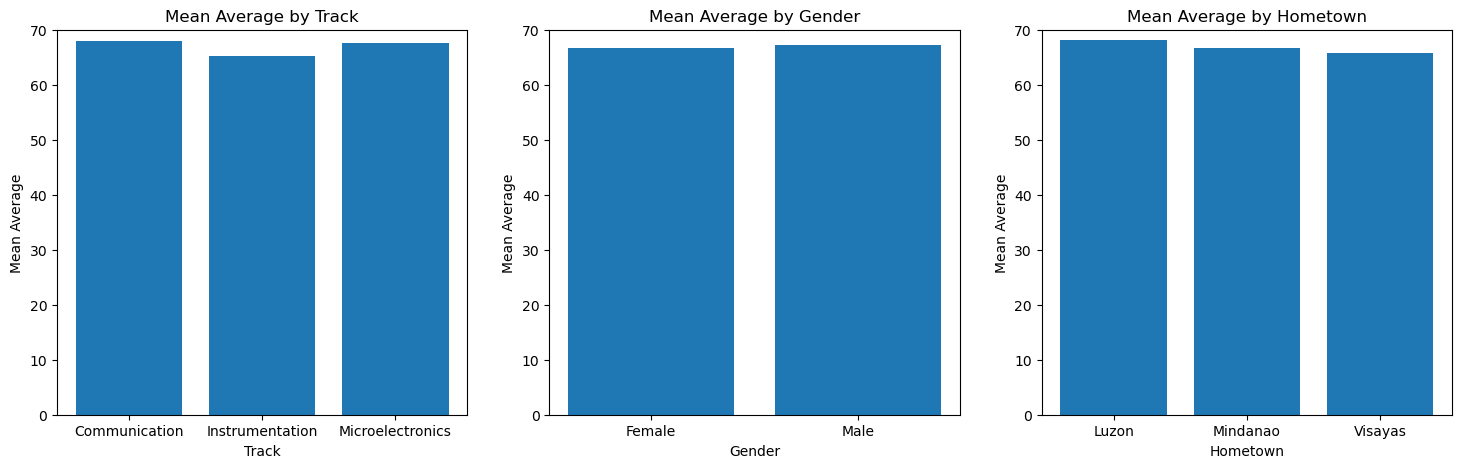

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].bar(Track_mean['Track'], Track_mean['Average'])
axes[0].set(title = 'Mean Average by Track')
axes[0].set(xlabel = 'Track')
axes[0].set(ylabel = 'Mean Average')
axes[0].set(ylim = (0, 70))

axes[1].bar(Gender_mean['Gender'], Gender_mean['Average'])
axes[1].set(title = 'Mean Average by Gender')
axes[1].set(xlabel = 'Gender')
axes[1].set(ylabel = 'Mean Average')
axes[1].set(ylim = (0, 70))

axes[2].bar(Hometown_mean['Hometown'], Hometown_mean['Average'])
axes[2].set(title = 'Mean Average by Hometown')
axes[2].set(xlabel = 'Hometown')
axes[2].set(ylabel = 'Mean Average')
axes[2].set(ylim = (0, 70))

Communication has the highest mean average in the Track category

Male has the highest mean avaerage in the Gender category

Luzon has the highest mean average in the Hometown category